# 2.1 — Базовые модели (MLP, GRU, TCN)

**Папка 2 «Обучение моделей», подноутбук 1.** Для каждой базовой модели выполняется
**подбор гиперпараметров перебором по сетке (grid search)** с богатой историей (все метрики
по каждой конфигурации). Метрика отбора выбирается явно. Лучшая комбинация сохраняется в
`models/<имя>/hyperparams.json`, после чего финальное обучение **читает этот JSON** и обучает
модель «начисто» с отслеживанием метрик. Рисунки и таблицы — на английском.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import (GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline,
                                    TransformerBaseline, FTTransformer, CatBoostBaseline,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow)

device: cpu | dims static/prefix/seq: 38 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Censored mean absolute error of the predicted ...
5,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
6,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
7,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...
8,ECE,Expected calibration error,–,lower is better,Average absolute gap between predicted confide...
9,Coverage_90,90% interval coverage,–,target ≈ 0.9,Empirical fraction of true PPR values that fal...


## Шаг 1. Grid search, история по всем метрикам и сохранение гиперпараметров

Для каждой модели задана своя метрика отбора `score` (можно менять). Дашборд показывает
все метрики по каждой конфигурации; лучшая по метрике отбора подсвечена.

[MLP-Risk] selection metric = Brier | best = {'hidden_dim': 128}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,128,0.6997,680.9850,932.5454,1.0850,1.4199,118.0,1.0,1.3887,675.0588,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,64,0.4840,628.5085,857.5118,1.0257,1.3266,118.0,1.0,1.3216,634.1147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


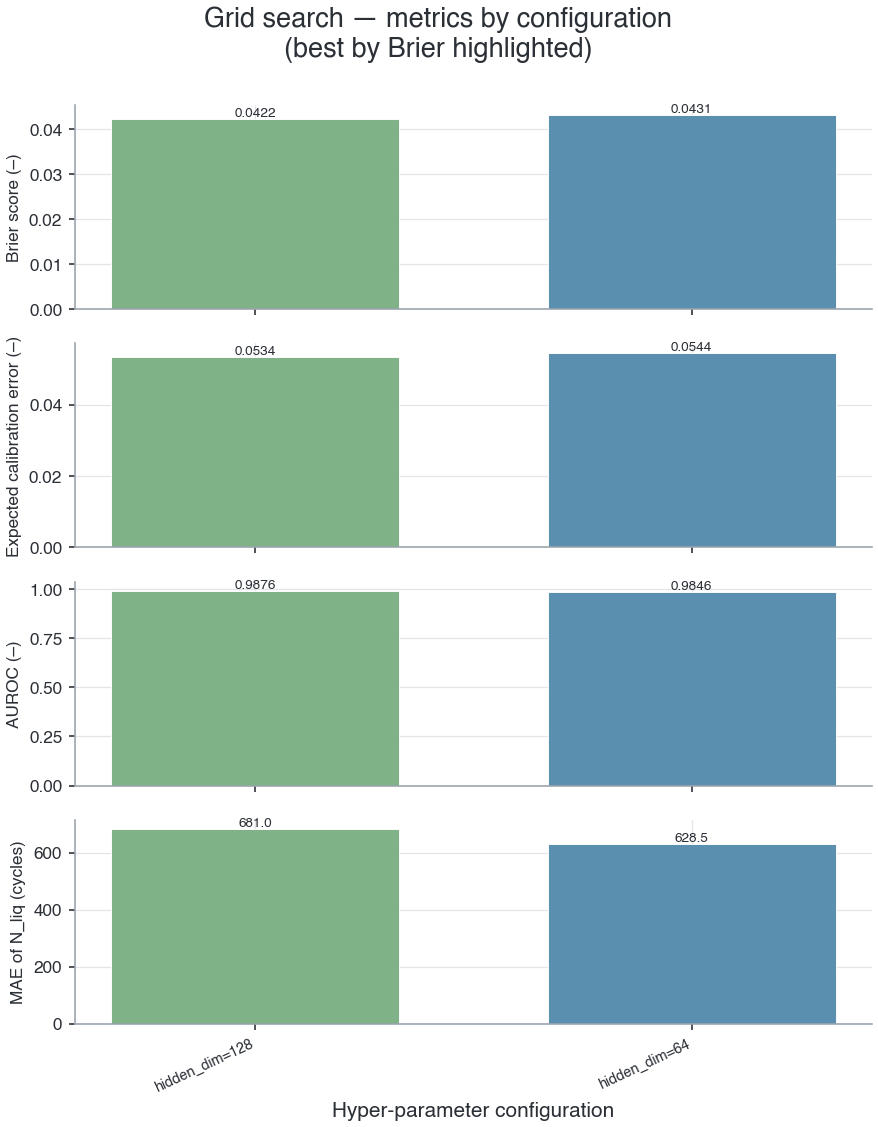

[GRU] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-1.5856,683.7924,888.6628,1.0657,1.3834,118.0,1.0,1.3310,608.2108,...,0.2799,0.8486,0.3335,0.1158,-0.6136,0.0651,NaN,0.0,0.0,0.0
1,64,-1.3365,562.8751,781.8235,0.8234,1.0439,118.0,1.0,0.9314,314.6921,...,0.3748,0.9018,0.4467,0.0574,-0.5275,0.0746,NaN,0.0,0.0,0.0


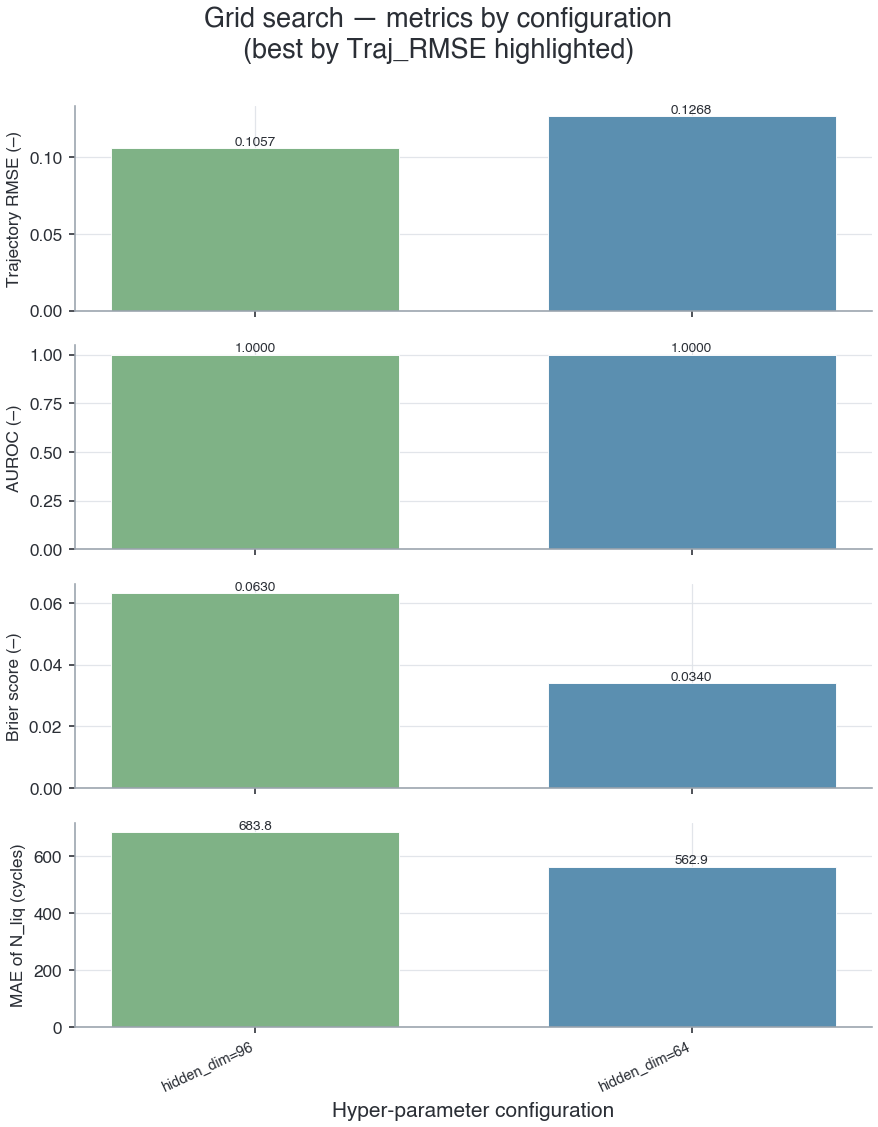

[TCN] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,64,-1.7713,1215.6129,1398.8589,1.8317,2.1793,118.0,1.0,2.4101,1398.7582,...,0.3015,0.9086,0.3593,0.0515,-0.8331,0.0596,NaN,0.0,0.0,0.0
1,96,-1.3930,602.4028,759.5721,1.1176,1.3450,118.0,1.0,1.4203,535.5690,...,0.2961,0.8960,0.3529,0.0848,-0.7428,0.0657,NaN,0.0,0.0,0.0


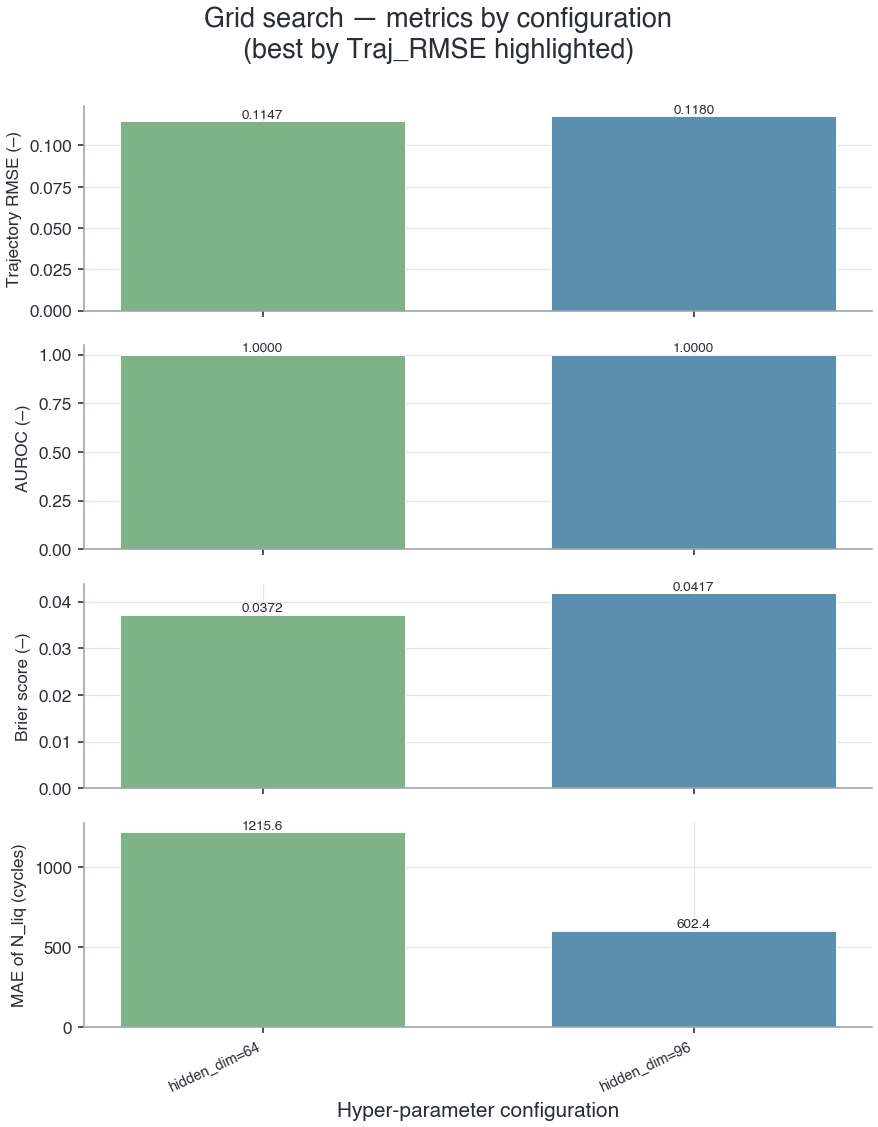

[LSTM] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-1.0647,683.0380,880.9828,1.1860,1.4213,118.0,1.0,1.5027,621.3334,...,0.2783,0.8163,0.3316,0.1545,-0.3250,0.0755,NaN,0.0,0.0,0.0
1,64,-1.2267,723.0351,898.9504,1.2021,1.3622,118.0,1.0,1.4308,500.6707,...,0.3837,0.8993,0.4572,0.0606,-0.4575,0.0781,NaN,0.0,0.0,0.0


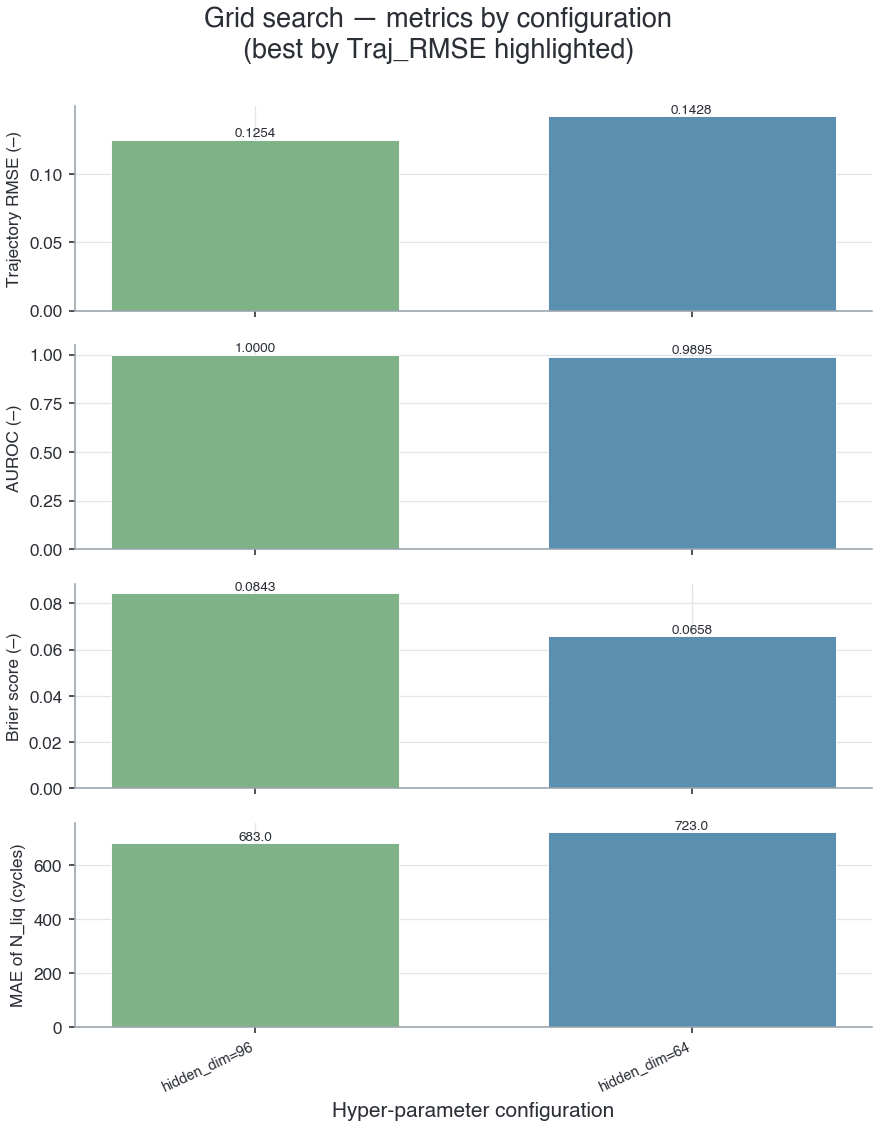

[Transformer] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-2.0767,532.0946,682.3275,1.1079,1.3102,118.0,1.0,1.4453,527.6062,...,0.2722,0.9425,0.3243,0.0120,-1.0801,0.0485,NaN,0.0,0.0,0.0
1,64,-1.8837,780.6305,907.2296,1.3496,1.5048,118.0,1.0,1.6444,598.2952,...,0.2528,0.8997,0.3012,0.0577,-1.0054,0.0523,NaN,0.0,0.0,0.0


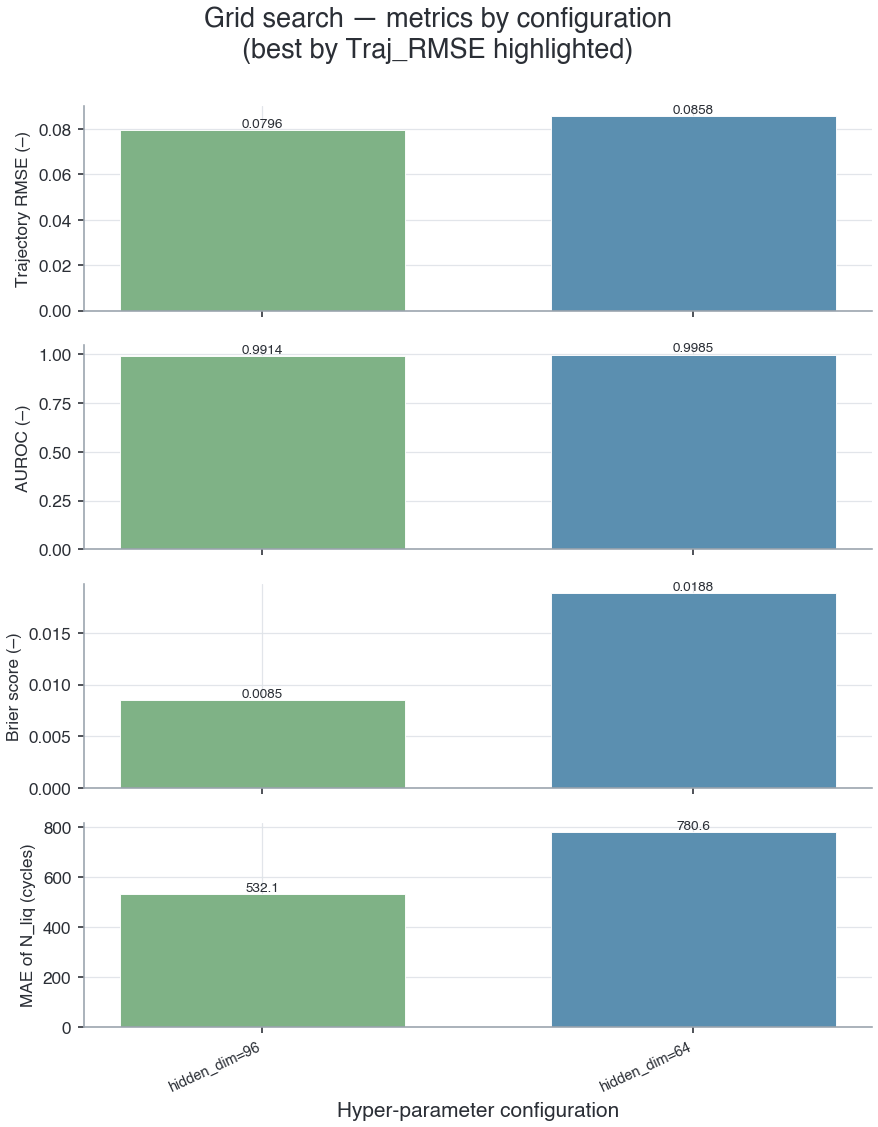

[FT-Transformer] selection metric = Brier | best = {'n_layers': 2}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,2,0.0187,194.3597,373.5863,0.4396,0.6384,118.0,1.0,0.5484,147.5813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,3,0.1954,567.6911,877.8711,0.7832,0.9704,118.0,1.0,0.8366,280.8818,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


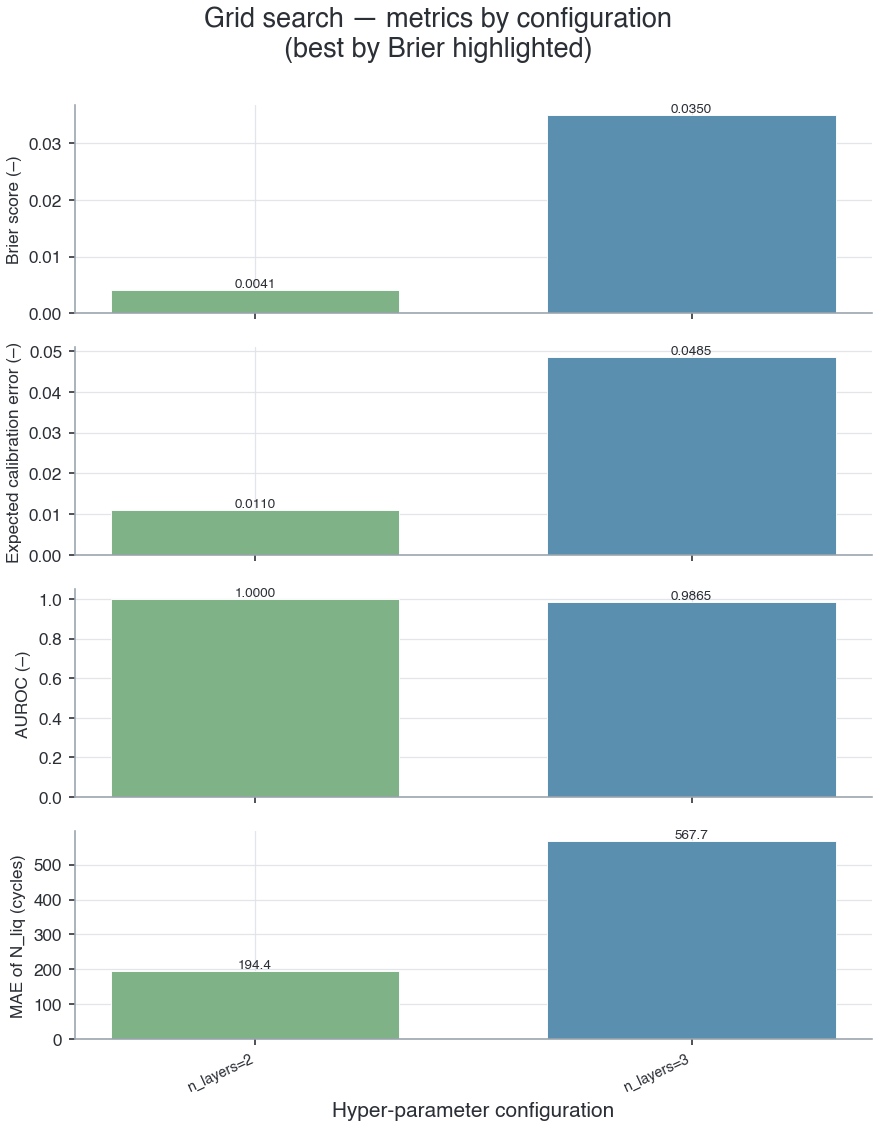

[PINN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-1.2733,1292.2532,1384.4573,1.9604,2.2653,118.0,1.0,2.6120,1563.1642,...,0.3651,0.9640,0.4351,0.0087,-0.8043,0.0613,NaN,0.0,0.0,0.0
1,64,-1.5289,962.0629,1035.4950,1.6378,1.8440,118.0,1.0,2.1063,970.5978,...,0.3031,0.9152,0.3612,0.0682,-0.6492,0.0656,NaN,0.0,0.0,0.0


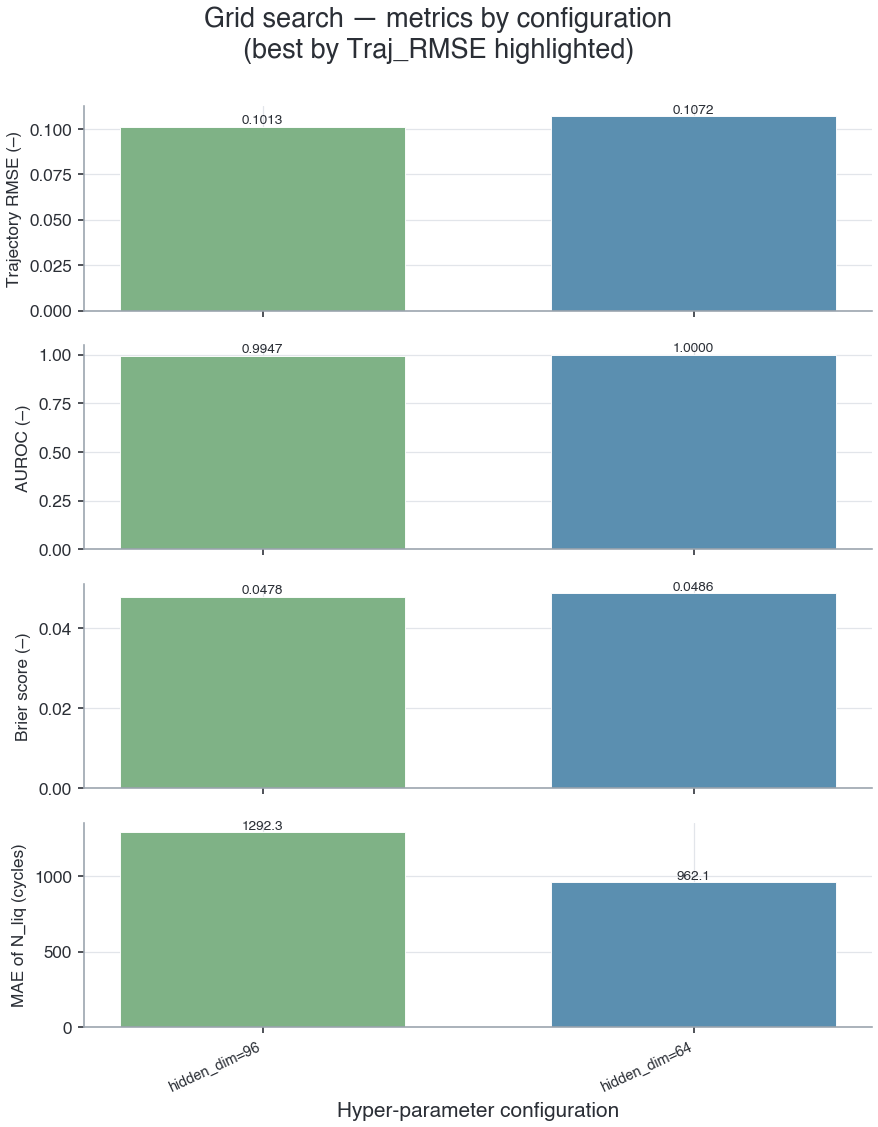

[DeepState] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-0.2462,798.5055,921.9894,1.3195,1.4770,118.0,1.0,1.5969,612.0450,...,0.2688,0.7988,0.3203,0.1690,-0.1062,0.0780,NaN,0.0,0.0,0.0
1,64,-1.1992,652.7850,880.5491,0.9488,1.1562,118.0,1.0,1.0801,398.8029,...,0.3816,0.8804,0.4546,0.0498,-0.3469,0.0815,NaN,0.0,0.0,0.0


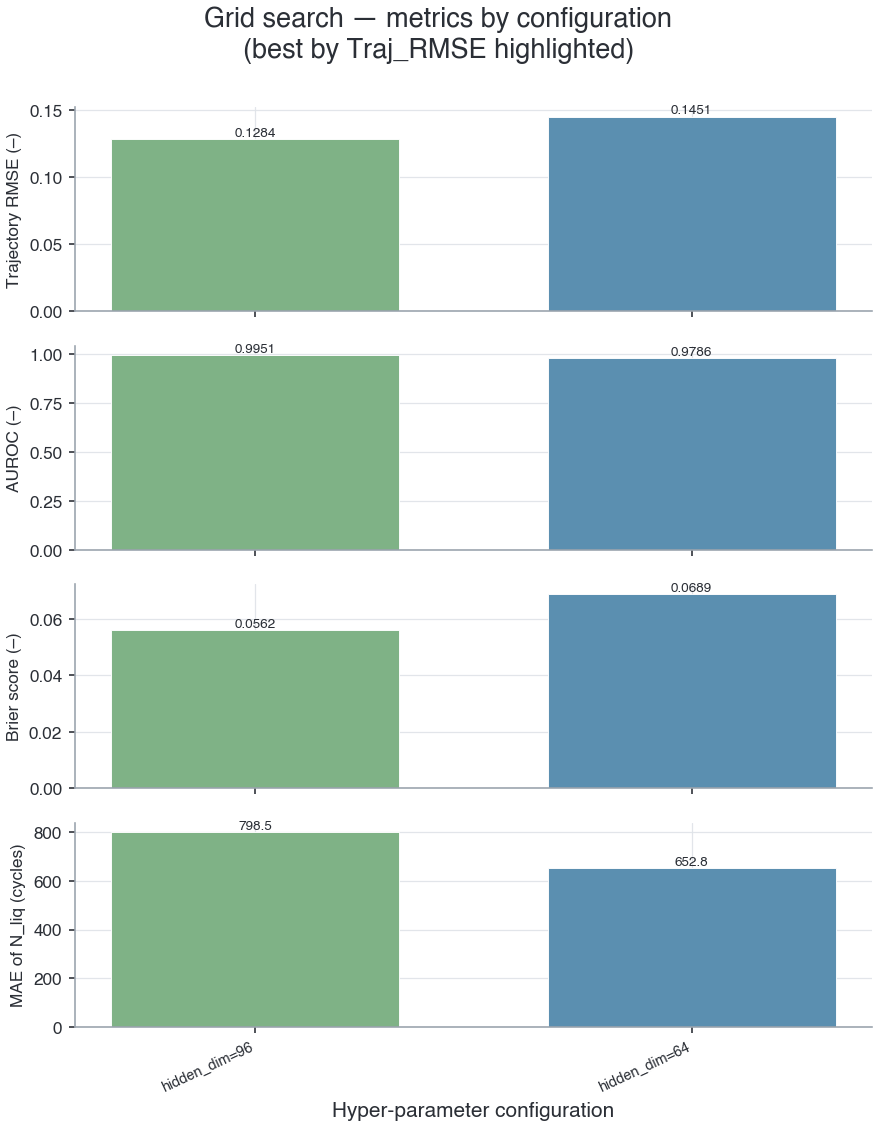

[RealNVP] selection metric = Traj_RMSE | best = {'n_layers': 4}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,4,1.1556,673.9851,1124.2716,0.7573,0.9475,118.0,1.0,0.5521,148.5236,...,0.6049,0.9757,0.7208,0.0361,-0.3955,0.0992,NaN,0.0,0.0,0.0
1,6,1.2339,723.2006,1288.8802,0.8439,1.0804,118.0,1.0,0.4741,85.5438,...,0.6435,0.9706,0.7668,0.0270,-0.3049,0.1048,NaN,0.0,0.0,0.0


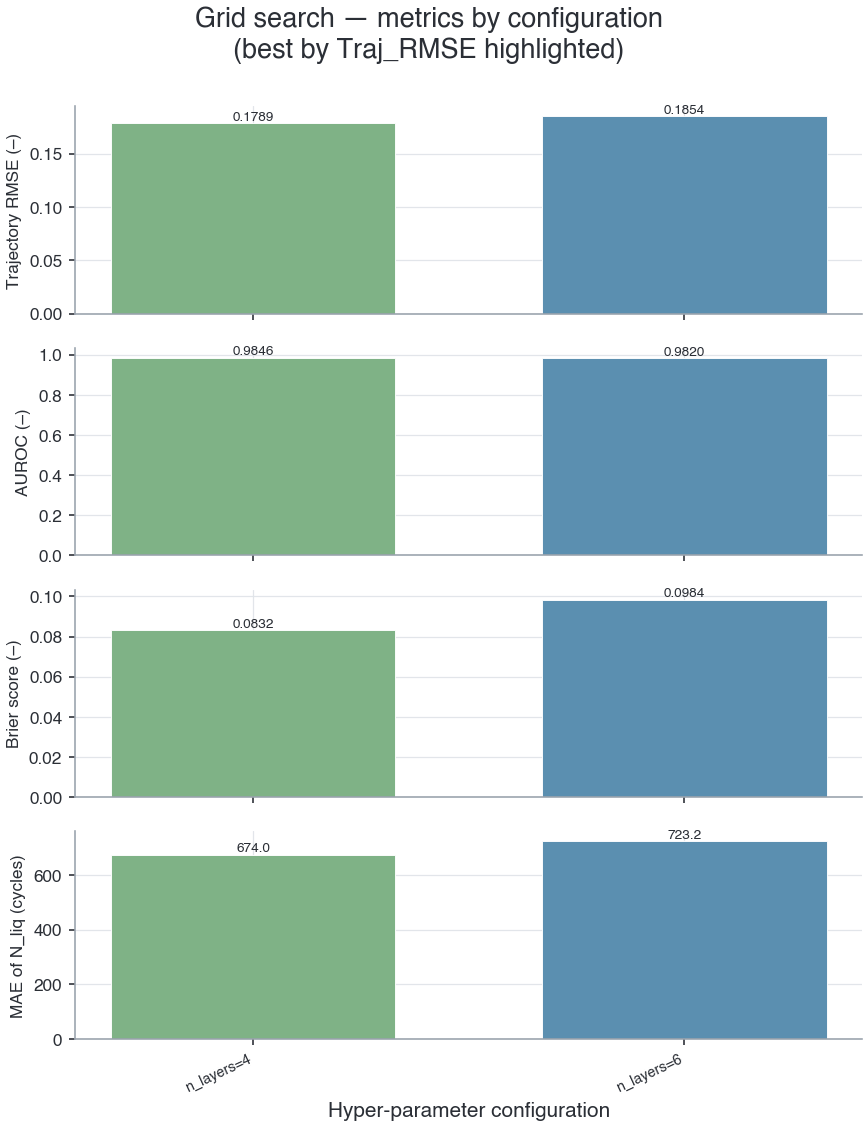

[Neural Spline Flow] selection metric = Traj_RMSE | best = {'n_layers': 5}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,5,11.1372,666.6310,1178.6722,0.7192,0.9114,118.0,1.0,0.4382,90.1012,...,0.5108,0.9061,0.6086,0.0497,-0.2369,0.1010,NaN,0.0,0.0,0.0
1,4,11.0533,603.9087,982.3409,0.7663,0.8697,118.0,1.0,0.6797,161.5476,...,0.5251,0.8970,0.6257,0.0632,-0.2041,0.1073,NaN,0.0,0.0,0.0


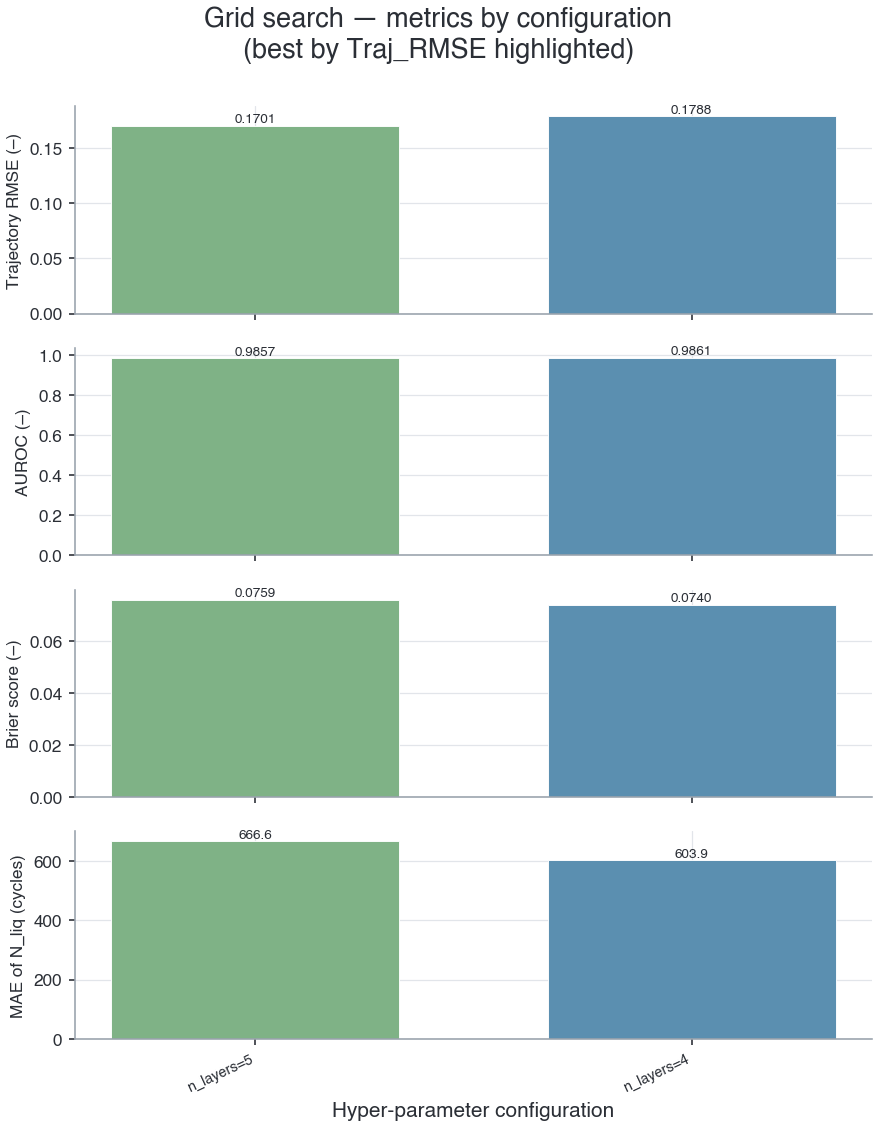

In [3]:
base_specs = {
    "mlp_risk": dict(display="MLP-Risk", cls=RiskMLP,
                     fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                     grid={"hidden_dim": [64, 128]}, score="Brier",
                     metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "gru": dict(display="GRU", cls=GRUBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "tcn": dict(display="TCN", cls=TCNBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "lstm": dict(display="LSTM", cls=LSTMBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "transformer": dict(display="Transformer", cls=TransformerBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim, seq_len=config.seq_len),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "ft_transformer": dict(display="FT-Transformer", cls=FTTransformer,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                 grid={"n_layers": [2, 3]}, score="Brier",
                 metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "pinn": dict(display="PINN", cls=PINNBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "deepstate": dict(display="DeepState", cls=DeepStateBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "realnvp": dict(display="RealNVP", cls=RealNVPFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 6]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "nsf": dict(display="Neural Spline Flow", cls=NeuralSplineFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 5]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
}

for name, spec in base_specs.items():
    cls, fixed, grid, score = spec["cls"], spec["fixed"], spec["grid"], spec["score"]
    res, best = grid_search(lambda p, cls=cls, fixed=fixed: cls(**fixed, **p),
                            grid, gs_train, gs_val, config, device, search_epochs=config.grid_search_epochs, score_metric=score)
    write_hyperparams(MODELS_DIR, name, {"model_type": cls.__name__, "display_name": spec["display"],
                      "model_kwargs": {**fixed, **best}, "search": {"grid": grid, "score_metric": score, "best": best}})
    print(f"[{spec['display']}] selection metric = {score} | best = {best}")
    display(english_metric_table(res).round(4))
    show_grid_dashboard(res, grid, score, spec["metrics"], f"2_1_grid_search_{name}").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
# Реестр классов всех baseline (имя класса -> класс) и число эпох по семействам
CLS = {RiskMLP.__name__: RiskMLP, GRUBaseline.__name__: GRUBaseline, TCNBaseline.__name__: TCNBaseline,
       LSTMBaseline.__name__: LSTMBaseline, TransformerBaseline.__name__: TransformerBaseline,
       FTTransformer.__name__: FTTransformer, PINNBaseline.__name__: PINNBaseline,
       DeepStateBaseline.__name__: DeepStateBaseline, RealNVPFlow.__name__: RealNVPFlow,
       NeuralSplineFlow.__name__: NeuralSplineFlow}
# PINN — физически-структурированная (больше эпох); остальные baseline — config.baseline_epochs
epoch_map = {name: (config.publication_physics_epochs if name == "pinn" else config.publication_baseline_epochs) for name in base_specs}
histories = {}
for name in base_specs:
    hp = read_hyperparams(MODELS_DIR, name)
    model = CLS[hp["model_type"]](**hp["model_kwargs"]).to(device)
    epochs = epoch_map[name]
    model, history = train_model(model, benchmark["train"], benchmark["val"], epochs=epochs,
                                 model_name=hp["display_name"], config=config, device=device, track_metrics=True)
    save_trained_model(model, MODELS_DIR, name, {**hp, "epochs": len(history), "learning_rate": config.learning_rate,
                       "weight_decay": config.weight_decay, "batch_size": config.batch_size, "seed": config.seed}, history)
    histories[hp["display_name"]] = history
    print("saved:", MODELS_DIR / name)

[MLP-Risk] эпоха 01 | обучение=0.6534 | валидация=0.2839 | val_AUROC=0.978 | stale=0/25
[MLP-Risk] эпоха 02 | обучение=0.2278 | валидация=0.2324 | val_AUROC=0.983 | stale=0/25
[MLP-Risk] эпоха 03 | обучение=0.1248 | валидация=0.1593 | val_AUROC=0.985 | stale=0/25
[MLP-Risk] эпоха 04 | обучение=0.0968 | валидация=0.2471 | val_AUROC=0.991 | stale=1/25
[MLP-Risk] эпоха 05 | обучение=0.0718 | валидация=0.3129 | val_AUROC=0.992 | stale=2/25
[MLP-Risk] эпоха 06 | обучение=0.0434 | валидация=0.2311 | val_AUROC=0.993 | stale=3/25
[MLP-Risk] эпоха 07 | обучение=0.0434 | валидация=0.2319 | val_AUROC=0.992 | stale=4/25
[MLP-Risk] эпоха 08 | обучение=0.0395 | валидация=0.4201 | val_AUROC=0.993 | stale=5/25
[MLP-Risk] эпоха 09 | обучение=0.0188 | валидация=0.5381 | val_AUROC=0.997 | stale=6/25
[MLP-Risk] эпоха 10 | обучение=0.0253 | валидация=0.4982 | val_AUROC=0.996 | stale=7/25
[MLP-Risk] эпоха 11 | обучение=0.0166 | валидация=0.3987 | val_AUROC=0.996 | stale=8/25
[MLP-Risk] эпоха 12 | обучение=0

## Кривые обучения с метриками

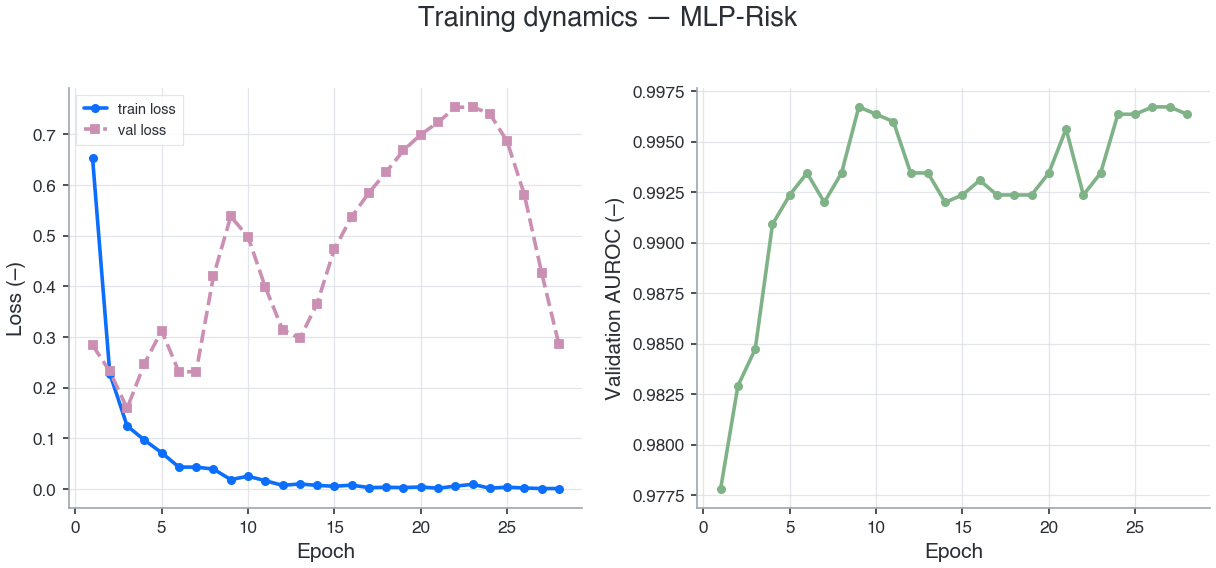

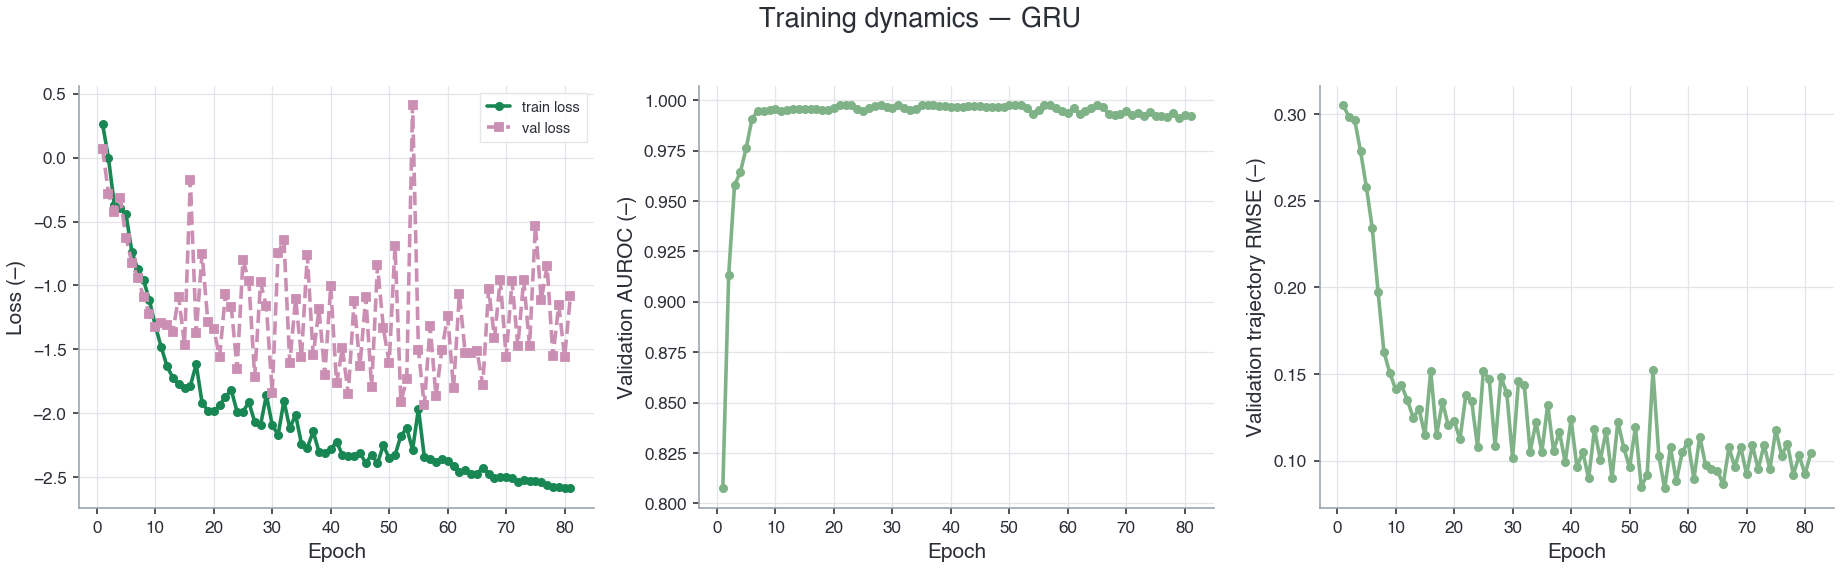

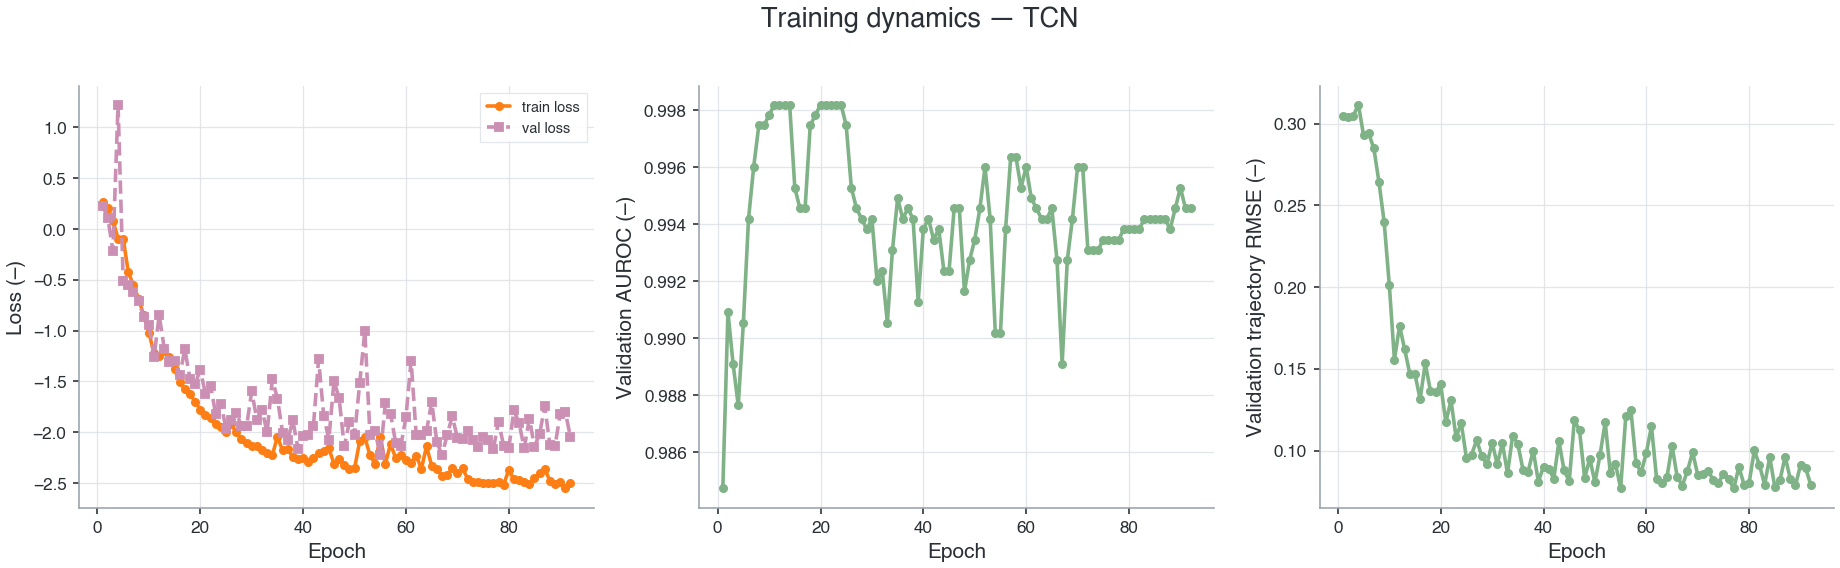

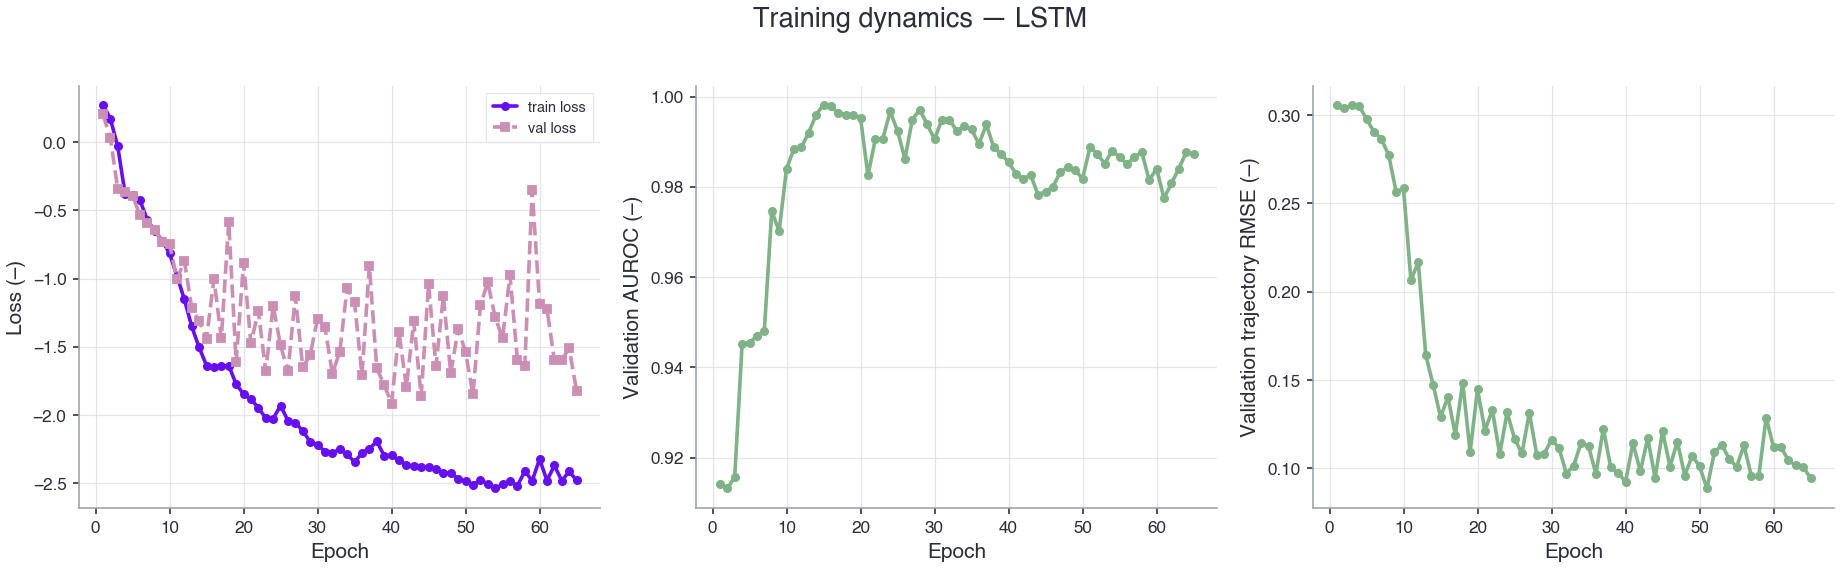

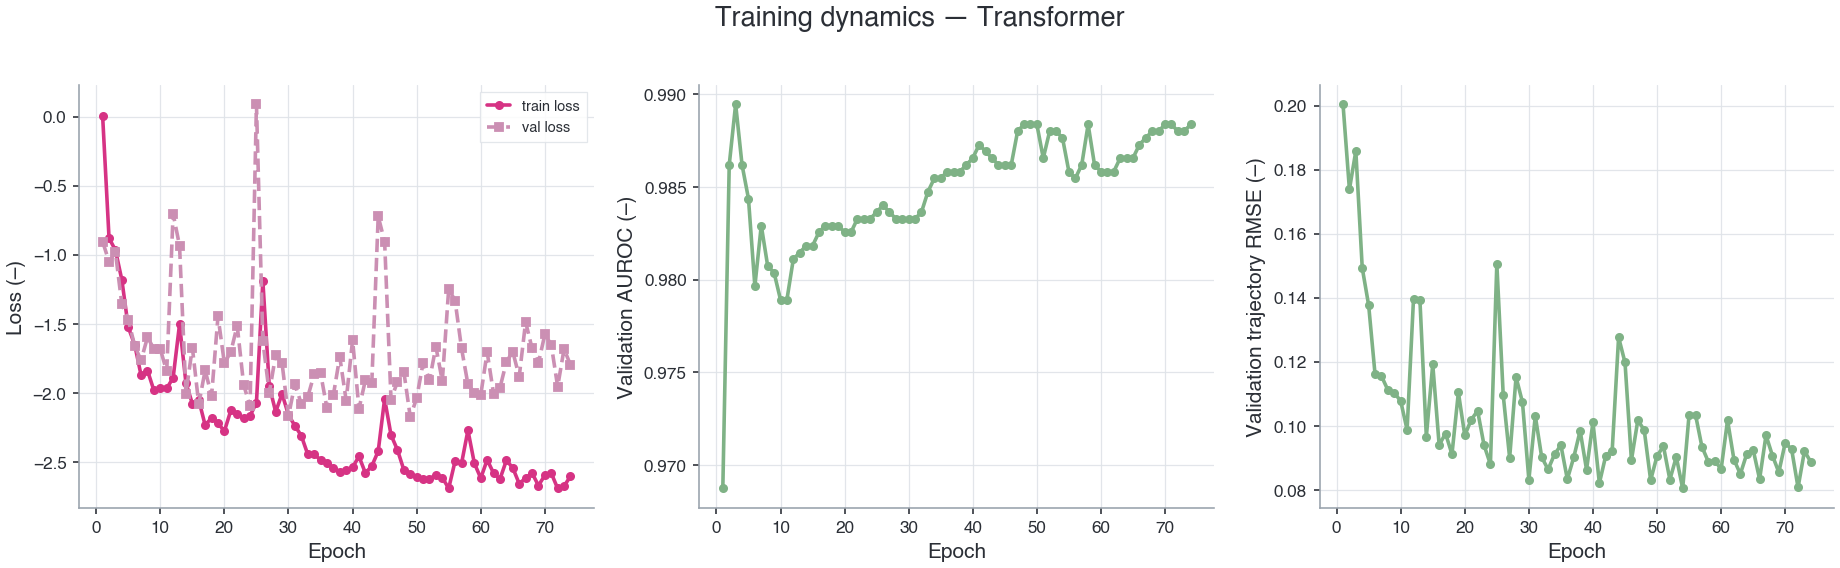

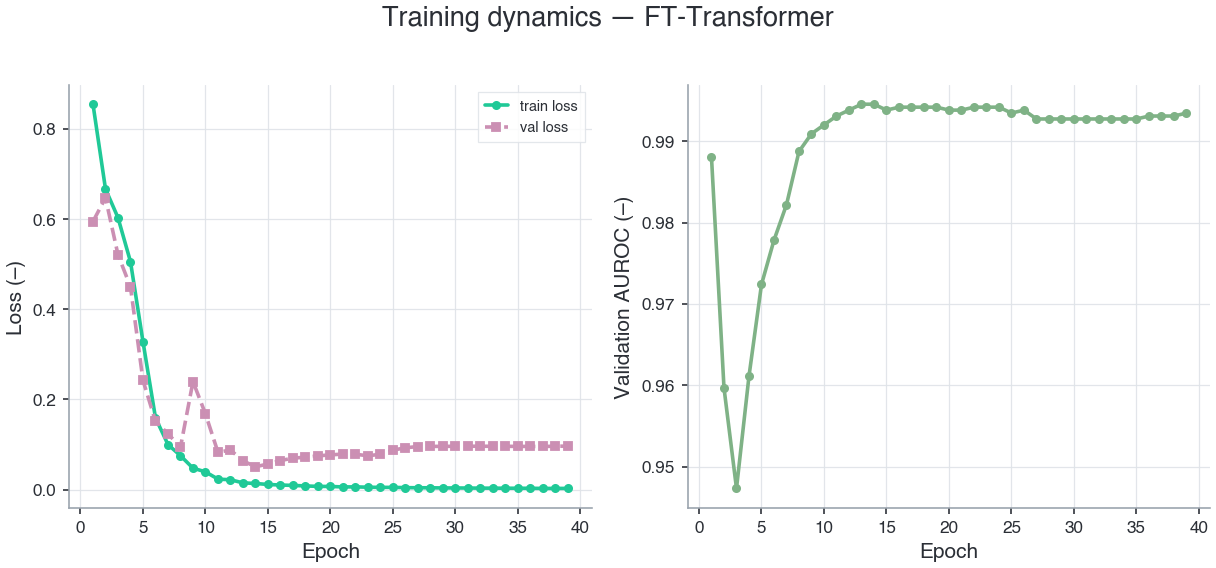

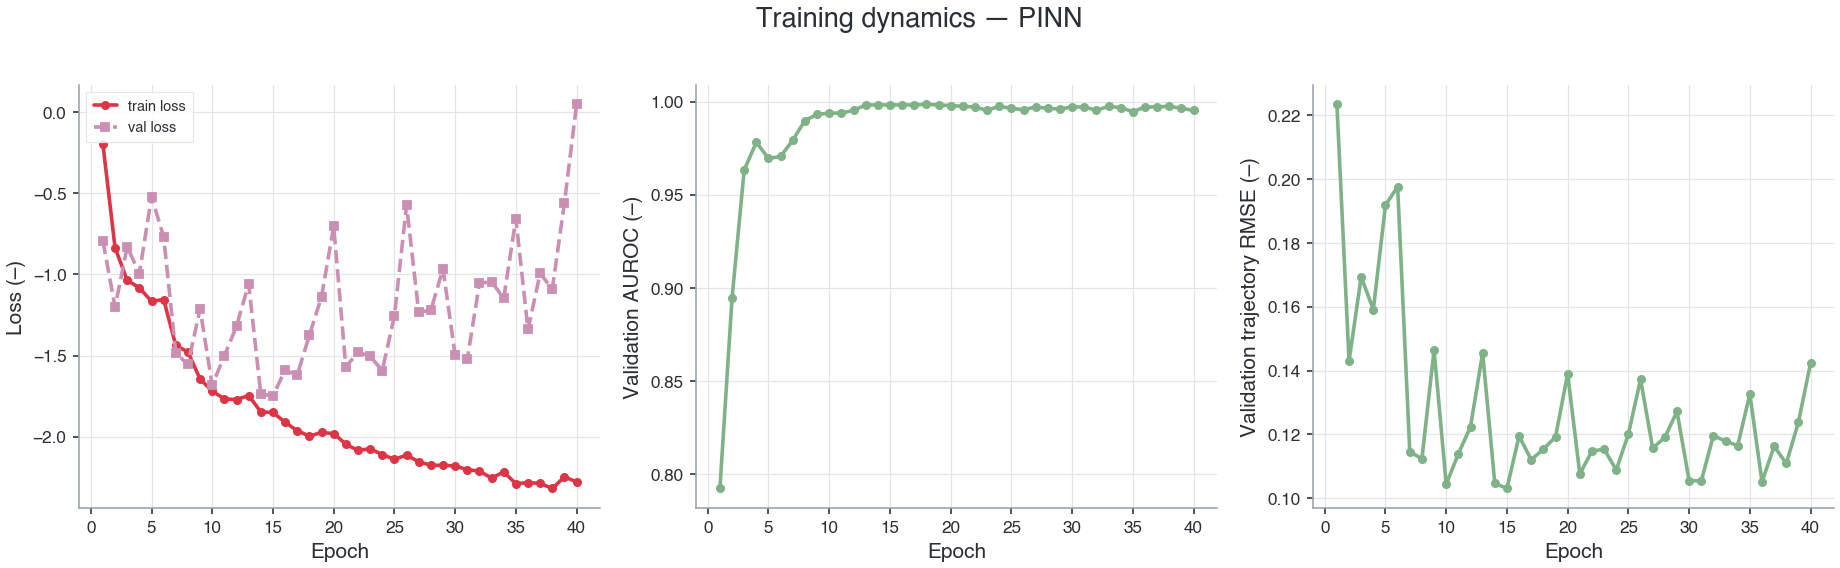

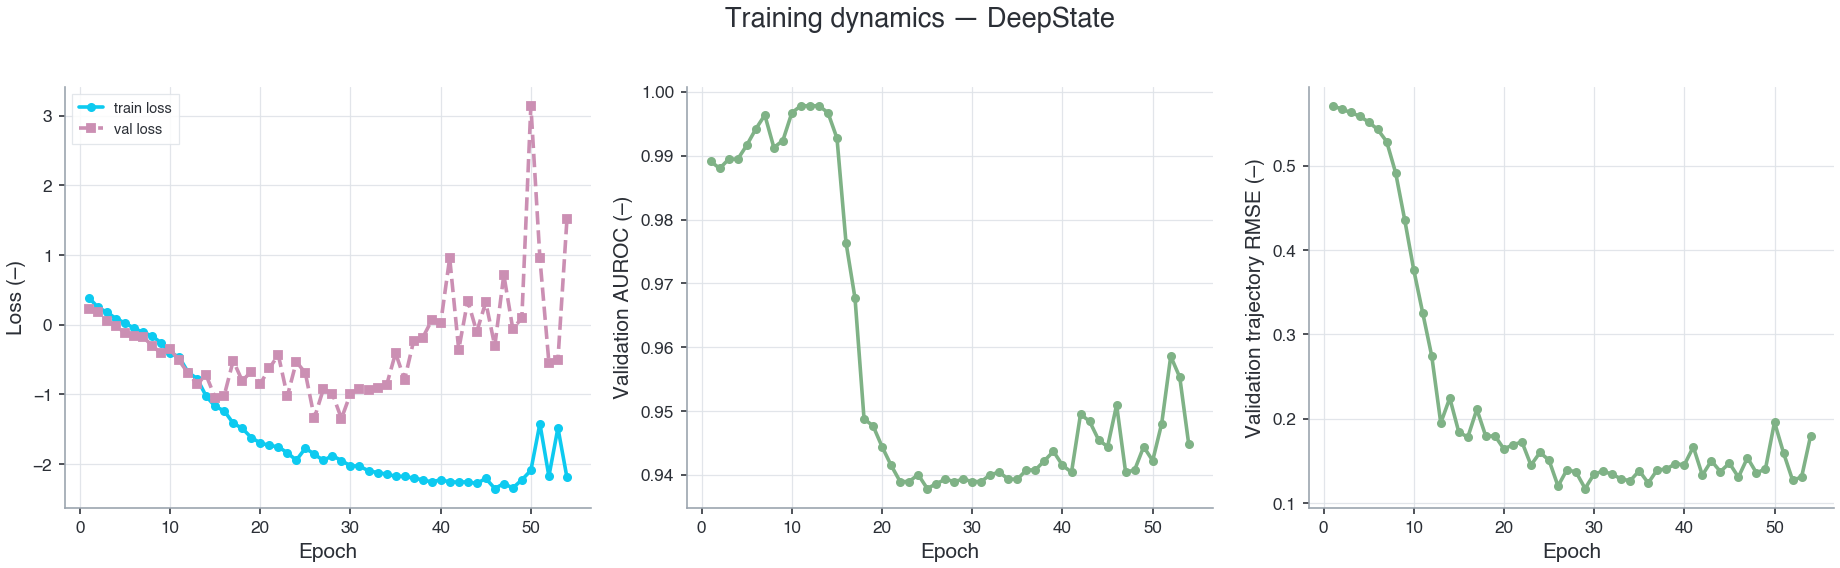

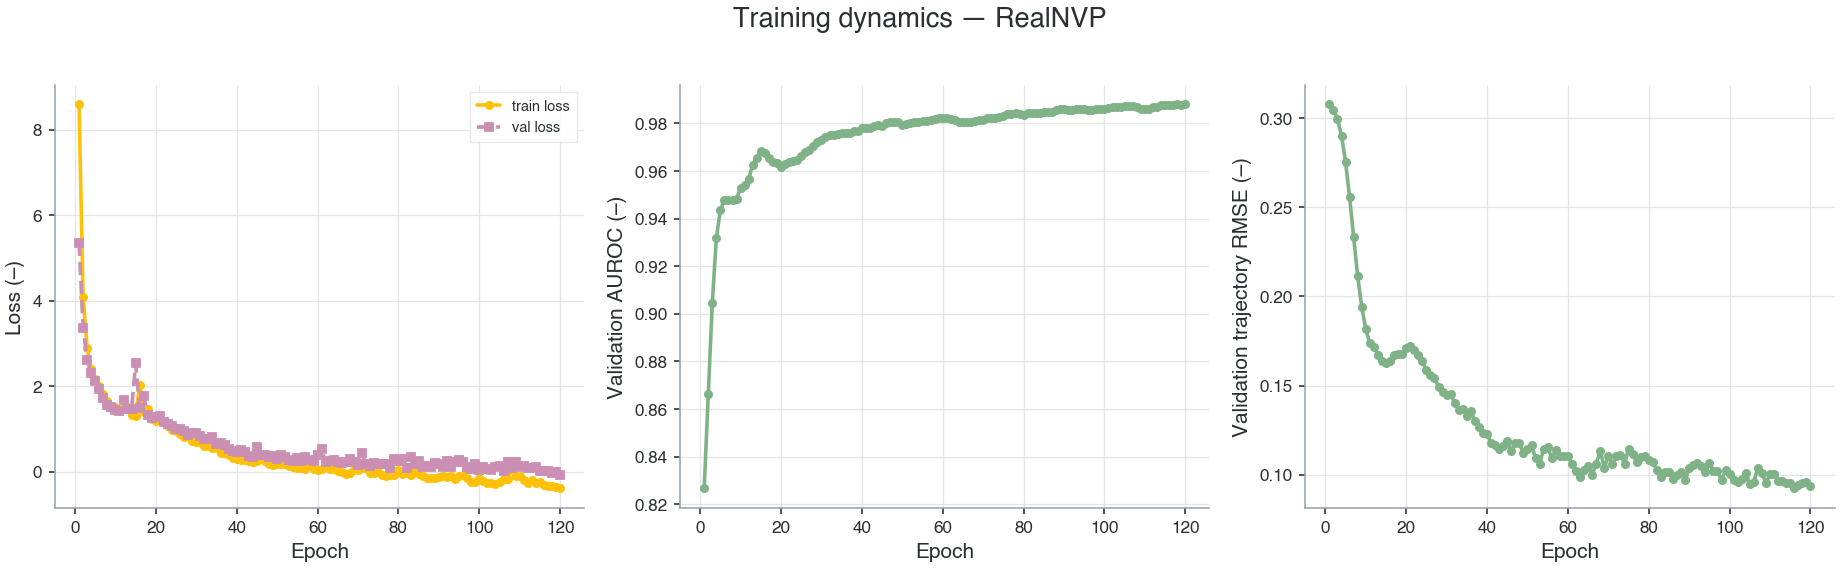

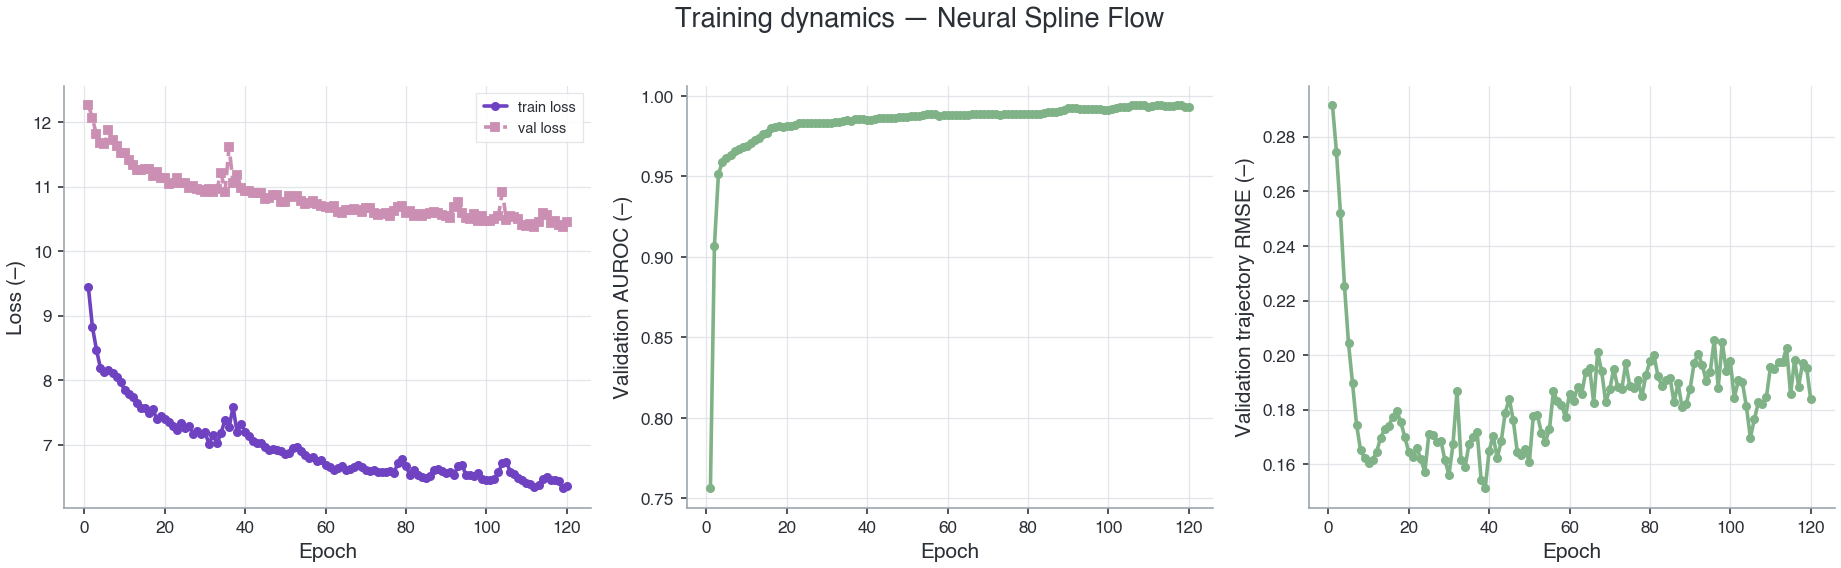

In [5]:
palette = ["#0b6efd", "#198754", "#fd7e14", "#6610f2", "#d63384", "#20c997", "#dc3545", "#0dcaf0", "#ffc107", "#6f42c1"]
colors = {disp: palette[i % len(palette)] for i, disp in enumerate(histories)}
for disp, hist in histories.items():
    training_dashboard(hist, title=f"Training dynamics — {disp}", model_color=colors[disp],
                       save=SAVE_FIGS, fig_id=f"2_1_training_{disp.lower().replace('-', '_')}").show()

## Итог

Базовые модели подобраны grid search (с выбором метрики) и обучены. Дальше — **2.2 DPI-Flow**.

In [6]:
# --- CatBoost (табличный градиентный бустинг) ---
# Не нейросеть, поэтому обучается своим .fit (не train_model) и сохраняется нативно.
cb = CatBoostBaseline(static_dim, prefix_dim).fit(benchmark["train"], benchmark["val"])
cb.save(MODELS_DIR, "catboost")
write_hyperparams(MODELS_DIR, "catboost", {"model_type": "CatBoostBaseline", "display_name": "CatBoost",
                  "model_kwargs": dict(static_dim=static_dim, prefix_dim=prefix_dim)})
print("saved:", MODELS_DIR / "catboost")

saved: /Users/nikita/Desktop/projects/liquefaction-ai/models/catboost
